# Timing + Fidelity Benchmark: 7 and 8 Qubits

For large systems (7–8 qubits), two separate models were trained:
- One using the **Magnus expansion** to compute U(t) from H_eff(t)
- One using the **Trotter decomposition** to compute U(t) from H_eff(t)

Each model is benchmarked with its corresponding integration method.
The baseline is **geodesic interpolation** via `fractional_matrix_power`.

For each method we report:
- **Wall-clock time** per query (mean ± std)
- **Gate fidelity** against the reference unitaries (mean ± std)

In [1]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt

from scipy.linalg import fractional_matrix_power
from req_prog.architectures import UnitaryModel
from req_prog.h_torch import unitary_magnus_torch, unitary_trotter_torch
from req_prog.h_magnus import fid_pros

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_QUBITS_LIST = [7, 8]
DELTA_T_BENCH = 0.1    # Δt used to select the trained model
N_REPS        = 100    # repetitions per method (must be <= 100, size of test grid)
STEPS         = 10     # integration steps inside Magnus / Trotter
SEED          = 42
rng           = np.random.default_rng(SEED)
device        = "cuda"

In [3]:
def load_model_large(n_qubits: int, delta_t: float, method: str, device: str = device) -> torch.nn.Module:
    """
    Load a trained model for large systems (7-8 qubits).
    Filename format: model{n}_deltat-{delta_t}-{method}.pth
    """
    model = UnitaryModel(n_qubits=n_qubits)
    path  = f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}-{method}.pth"
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model


def fid_pros(U1: np.ndarray, U2: np.ndarray) -> float:
    """Gate fidelity between two unitary matrices."""
    d  = U1.shape[0]
    Tr = np.trace(U1.conj().T @ U2)
    return (np.abs(Tr) / d) ** 2


def benchmark_pinn(
    model: torch.nn.Module,
    n: int,
    method: str,
    U_target: np.ndarray,
    time_grid: np.ndarray,
    n_reps: int,
    steps: int
) -> dict:
    """
    Measure timing and fidelity for one PINN method.

    Queries are made at the same time points used in U_target
    so that fidelity can be computed exactly (no interpolation needed).

    Parameters
    ----------
    U_target : np.ndarray
        Shape (100, d, d) — reference unitaries on a uniform grid in [0, 1].
    time_grid : np.ndarray
        Shape (100,) — the corresponding time values.
    """
    fn      = unitary_magnus_torch if method == "magnus" else unitary_trotter_torch
    indices = rng.choice(len(time_grid), size=n_reps, replace=False)

    wall_times  = []
    fidelities  = []

    with torch.no_grad():
        for idx in indices:
            t_val   = float(time_grid[idx])
            t_query = torch.tensor([[t_val]], dtype=torch.float32, device=next(model.parameters()).device)
            U_ref   = U_target[idx]          # (d, d) complex numpy

            t0      = time.perf_counter()
            U_pred  = fn(model=model, time=t_query, steps=steps, n=n)
            t1      = time.perf_counter()

            U_pred_np = U_pred[0].cpu().detach().numpy()   # (d, d)

            wall_times.append(t1 - t0)
            fidelities.append(fid_pros(U_pred_np, U_ref))

    return {
        "times" : np.array(wall_times),
        "fids"  : np.array(fidelities)
    }


def benchmark_geodesic(
    U_known: np.ndarray,
    U_target: np.ndarray,
    time_grid: np.ndarray,
    n_reps: int
) -> dict:
    """
    Measure timing and fidelity for geodesic interpolation.

    U_known defines the coarse grid used for interpolation.
    U_target provides the reference unitaries for fidelity evaluation.
    """
    K          = U_known.shape[0]
    t_known    = np.linspace(0.0, 1.0, K)
    delta_t    = t_known[1] - t_known[0]
    indices    = rng.choice(len(time_grid), size=n_reps, replace=False)

    wall_times = []
    fidelities = []

    for idx in indices:
        t_query = float(time_grid[idx])
        U_ref   = U_target[idx]

        # Locate left bracket
        if t_query >= t_known[-1]:
            i_left = K - 2
        else:
            i_left = int(np.searchsorted(t_known, t_query, side="right") - 1)
            i_left = max(i_left, 0)

        alpha = (t_query - t_known[i_left]) / delta_t
        U0    = U_known[i_left]
        U1    = U_known[i_left + 1]

        t0    = time.perf_counter()
        W     = U1 @ np.conj(U0).T
        U_int = fractional_matrix_power(W, alpha) @ U0
        t1    = time.perf_counter()

        wall_times.append(t1 - t0)
        fidelities.append(fid_pros(U_int, U_ref))

    return {
        "times" : np.array(wall_times),
        "fids"  : np.array(fidelities)
    }

In [4]:
# ── Run benchmark ─────────────────────────────────────────────────────────────
# results[n] = {"magnus": {"times": arr, "fids": arr}, "trotter": ..., "interp": ...}
results   = {}
time_grid = np.linspace(0.0, 1.0, 100)

for n in N_QUBITS_LIST:
    print(f"\nBenchmarking N={n} qubits ({N_REPS} reps, steps={STEPS}) ...")
    results[n] = {}

    U_known  = np.load(f"dataframe/unitary_N{n}.npy")       # coarse grid (K, d, d)
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")  # fine grid (100, d, d)

    for method in ("magnus", "trotter"):
        model = load_model_large(n, DELTA_T_BENCH, method)

        # Warmup
        fn = unitary_magnus_torch if method == "magnus" else unitary_trotter_torch
        with torch.no_grad():
            t_w = torch.tensor([[0.5]], dtype=torch.float32)
            t_w = t_w.to(next(model.parameters()).device)
            for _ in range(5):
                fn(model=model, time=t_w, steps=STEPS, n=n)

        res = benchmark_pinn(
            model=model, n=n, method=method,
            U_target=U_target, time_grid=time_grid,
            n_reps=N_REPS, steps=STEPS
        )
        results[n][method] = res
        print(
            f"  PINN + {method:<7}: "
            f"time = {res['times'].mean()*1e3:.3f} +/- {res['times'].std()*1e3:.3f} ms  |  "
            f"fidelity = {res['fids'].mean():.5f} +/- {res['fids'].std():.5f}"
        )

    res_geo = benchmark_geodesic(
        U_known=U_known, U_target=U_target,
        time_grid=time_grid, n_reps=N_REPS
    )
    results[n]["interp"] = res_geo
    print(
        f"  Geodesic       : "
        f"time = {res_geo['times'].mean()*1e3:.3f} +/- {res_geo['times'].std()*1e3:.3f} ms  |  "
        f"fidelity = {res_geo['fids'].mean():.5f} +/- {res_geo['fids'].std():.5f}"
    )

print("\nDone.")


Benchmarking N=7 qubits (100 reps, steps=10) ...
  PINN + magnus : time = 12.222 +/- 2.283 ms  |  fidelity = 0.99882 +/- 0.00068
  PINN + trotter: time = 4.583 +/- 1.870 ms  |  fidelity = 0.99880 +/- 0.00068
  Geodesic       : time = 39.456 +/- 27.395 ms  |  fidelity = 0.99981 +/- 0.00015

Benchmarking N=8 qubits (100 reps, steps=10) ...
  PINN + magnus : time = 22.885 +/- 5.790 ms  |  fidelity = 0.99842 +/- 0.00083
  PINN + trotter: time = 7.412 +/- 1.087 ms  |  fidelity = 0.99733 +/- 0.00204
  Geodesic       : time = 174.525 +/- 194.155 ms  |  fidelity = 0.99979 +/- 0.00017

Done.


In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
header = (
    f"{'N':>4}  {'Method':<16}  {'Time mean (ms)':>14}  {'Time std (ms)':>13}  "
    f"{'Fidelity mean':>14}  {'Fidelity std':>13}  {'Speedup':>8}"
)
print(header)
print("-" * len(header))

for n in N_QUBITS_LIST:
    ref_time = results[n]["interp"]["times"].mean()
    for label, key in [("PINN + Magnus", "magnus"),
                       ("PINN + Trotter", "trotter"),
                       ("Geodesic", "interp")]:
        tm = results[n][key]["times"].mean() * 1e3
        ts = results[n][key]["times"].std()  * 1e3
        fm = results[n][key]["fids"].mean()
        fs = results[n][key]["fids"].std()
        sp = ref_time / results[n][key]["times"].mean()
        print(f"{n:>4}  {label:<16}  {tm:>14.3f}  {ts:>13.3f}  {fm:>14.5f}  {fs:>13.5f}  {sp:>8.2f}x")
    print()

   N  Method            Time mean (ms)  Time std (ms)   Fidelity mean   Fidelity std   Speedup
----------------------------------------------------------------------------------------------
   7  PINN + Magnus             12.222          2.283         0.99882        0.00068      3.23x
   7  PINN + Trotter             4.583          1.870         0.99880        0.00068      8.61x
   7  Geodesic                  39.456         27.395         0.99981        0.00015      1.00x

   8  PINN + Magnus             22.885          5.790         0.99842        0.00083      7.63x
   8  PINN + Trotter             7.412          1.087         0.99733        0.00204     23.55x
   8  Geodesic                 174.525        194.155         0.99979        0.00017      1.00x



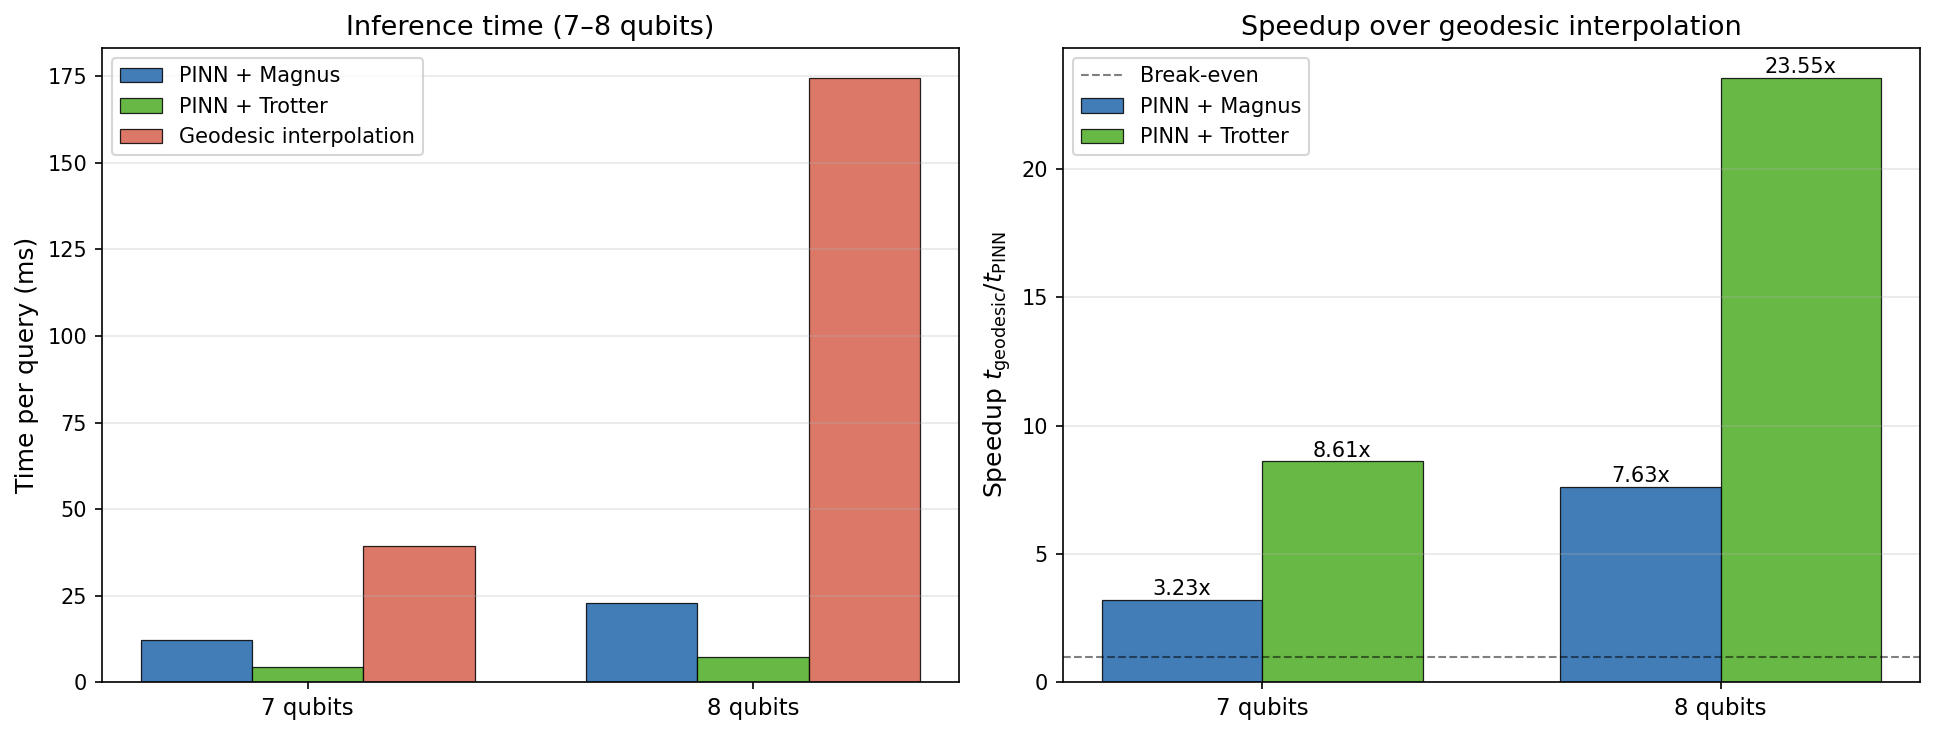

Figure saved to figures/timing_benchmark_large.pdf


In [6]:
# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

colors = {
    "magnus" : "#2166ac",
    "trotter": "#4dac26",
    "interp" : "#d6604d"
}
labels = {
    "magnus" : "PINN + Magnus",
    "trotter": "PINN + Trotter",
    "interp" : "Geodesic interpolation"
}

x_pos   = np.arange(len(N_QUBITS_LIST))
width   = 0.25
offsets = {"magnus": -width, "trotter": 0.0, "interp": width}

# ── Left panel: absolute times ────────────────────────────────────────────────
ax = axes[0]
for key in ("magnus", "trotter", "interp"):
    means = np.array([results[n][key]["times"].mean() * 1e3 for n in N_QUBITS_LIST])
    ax.bar(
        x_pos + offsets[key], means, width=width,
        label=labels[key], color=colors[key],
        alpha=0.85, edgecolor="k", linewidth=0.6
    )

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{n} qubits" for n in N_QUBITS_LIST], fontsize=11)
ax.set_ylabel("Time per query (ms)", fontsize=12)
ax.set_title("Inference time (7–8 qubits)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# ── Right panel: speedup ratio (geodesic / PINN) ──────────────────────────────
ax2    = axes[1]
width2 = 0.35

for key, offset in [("magnus", -width2 / 2), ("trotter", width2 / 2)]:
    speedup = np.array(
        [results[n]["interp"]["times"].mean() / results[n][key]["times"].mean()
         for n in N_QUBITS_LIST]
    )
    ax2.bar(
        x_pos + offset, speedup, width=width2,
        label=labels[key], color=colors[key],
        alpha=0.85, edgecolor="k", linewidth=0.6
    )
    for xi, s in zip(x_pos + offset, speedup):
        ax2.text(xi, s + 0.02, f"{s:.2f}x",
                 ha="center", va="bottom", fontsize=10)

ax2.axhline(1, color="k", lw=1, ls="--", alpha=0.5, label="Break-even")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{n} qubits" for n in N_QUBITS_LIST], fontsize=11)
ax2.set_ylabel(r"Speedup $t_\mathrm{geodesic} / t_\mathrm{PINN}$", fontsize=12)
ax2.set_title("Speedup over geodesic interpolation", fontsize=13)
ax2.set_ylim([0, None])
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# plt.suptitle(
#     f"Timing benchmark — 7 and 8 qubits ({N_REPS} reps, {STEPS} integration steps)",
#     fontsize=12, y=1.02
# )
plt.tight_layout()
plt.savefig("figures/timing_benchmark_large.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to figures/timing_benchmark_large.pdf")

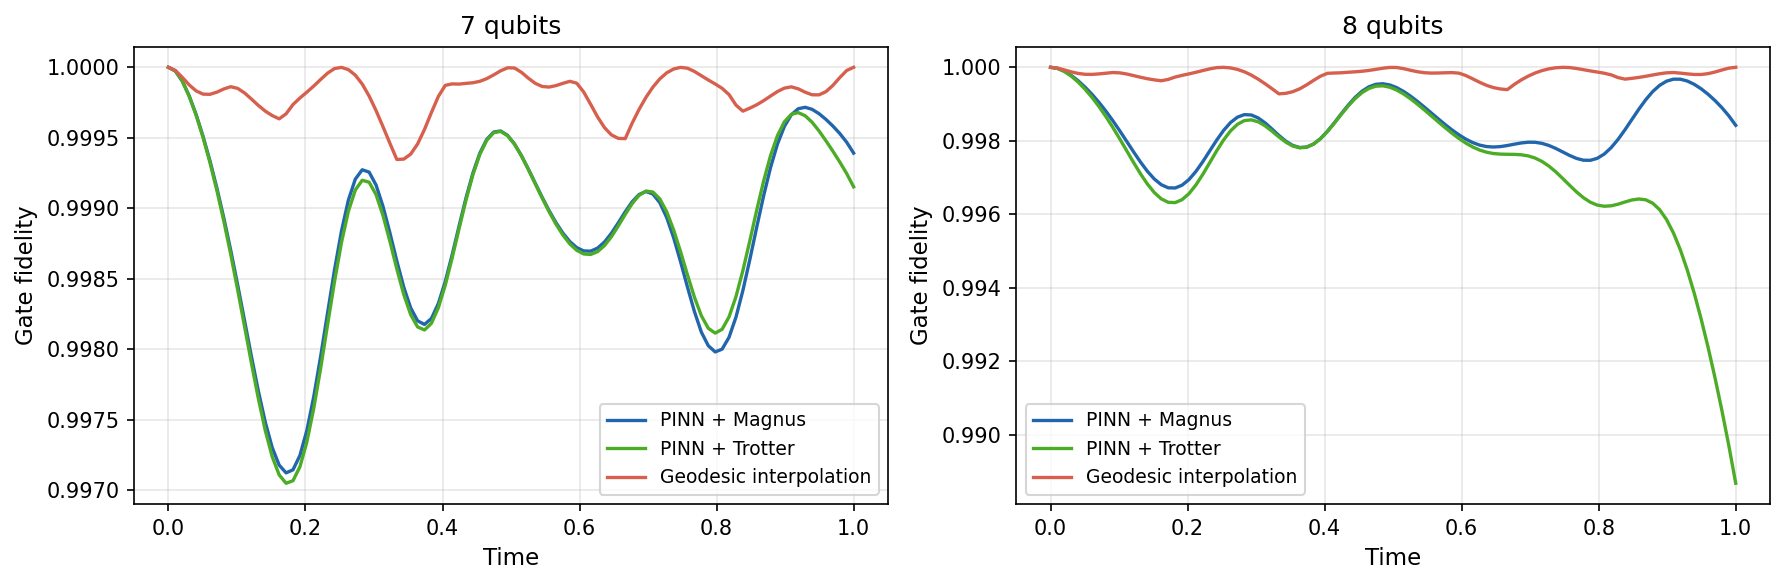

In [7]:
# ── Accuracy comparison: PINN vs Geodesic (7-8 qubits) ───────────────────────
time_grid     = np.linspace(0.0, 1.0, 100)
fid_results_l = {}   # {n: {"magnus": arr, "trotter": arr, "interp": arr}}

for n in N_QUBITS_LIST:
    U_known  = np.load(f"dataframe/unitary_N{n}.npy")
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")
    K        = U_known.shape[0]
    t_known  = np.linspace(0.0, 1.0, K)
    delta_t  = t_known[1] - t_known[0]
    fid_results_l[n] = {}

    for method in ("magnus", "trotter"):
        model = load_model_large(n, DELTA_T_BENCH, method)
        fn    = unitary_magnus_torch if method == "magnus" else unitary_trotter_torch
        fids  = []
        with torch.no_grad():
            for idx, t in enumerate(time_grid):
                U_ref  = U_target[idx]
                t_tens = torch.tensor([[t]], dtype=torch.float32, device=next(model.parameters()).device)
                U_pred = fn(model=model, time=t_tens, steps=STEPS, n=n)[0].cpu().detach().numpy()
                fids.append(fid_pros(U_pred, U_ref))
        fid_results_l[n][method] = np.array(fids)

    # Geodesic
    fids_geo = []
    for idx, t in enumerate(time_grid):
        U_ref  = U_target[idx]
        if t >= t_known[-1]:
            i_left = K - 2
        else:
            i_left = max(int(np.searchsorted(t_known, t, side="right") - 1), 0)
        alpha  = (t - t_known[i_left]) / delta_t
        W      = U_known[i_left + 1] @ np.conj(U_known[i_left]).T
        U_geo  = fractional_matrix_power(W, alpha) @ U_known[i_left]
        fids_geo.append(fid_pros(U_geo, U_ref))
    fid_results_l[n]["interp"] = np.array(fids_geo)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
colors = {"magnus": "#2166ac", "trotter": "#4dac26", "interp": "#d6604d"}
labels = {"magnus": "PINN + Magnus", "trotter": "PINN + Trotter",
          "interp": "Geodesic interpolation"}

for col, n in enumerate(N_QUBITS_LIST):
    ax = axes[col]
    for key in ("magnus", "trotter", "interp"):
        ax.plot(time_grid, fid_results_l[n][key],
                color=colors[key], lw=1.6, label=labels[key])
    ax.set_title(f"{n} qubits", fontsize=12)
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("Gate fidelity", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# plt.suptitle(
#     f"Gate fidelity — PINN vs Geodesic ($\\Delta t = {DELTA_T_BENCH}$, {STEPS} steps)",
#     fontsize=12, y=1.02
# )
plt.tight_layout()
plt.savefig("figures/accuracy_comparison_large.pdf", bbox_inches="tight")
plt.show()